In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. DATA GENERATION
def load_coffee_data():
    """ Creates a coffee roasting data set.
            roasting duration: 12-15 minutes is best
            temperature range: 175-260C is best
        """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 1] = X[:, 1] * 4 + 11.5  # 12-15 min is best
    X[:, 0] = X[:, 0] * (285 - 150) + 150  # 175-260 C is best
    Y = np.zeros(len(X))

    i = 0
    for t, d in X:
        y = -3 / (260 - 175) * t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d <= y):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1
    return (X, Y.reshape(-1, 1))

In [6]:
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np 


In [8]:
X,Y = load_coffee_data()

X_mean=X.mean(axis=0)
X_std=X.std(axis=0)
X_scaled= (X-X_mean)/X_std

X_tensor=torch.tensor(X_scaled,dtype=torch.float32)
Y_tensor=torch.tensor(Y,dtype=torch.float32)

Training the  deep NN 
Epoch[200],Loss:0.0120
Epoch[400],Loss:0.0022
Epoch[600],Loss:0.0007
Epoch[800],Loss:0.0003
Epoch[1000],Loss:0.0002
Training Complete 



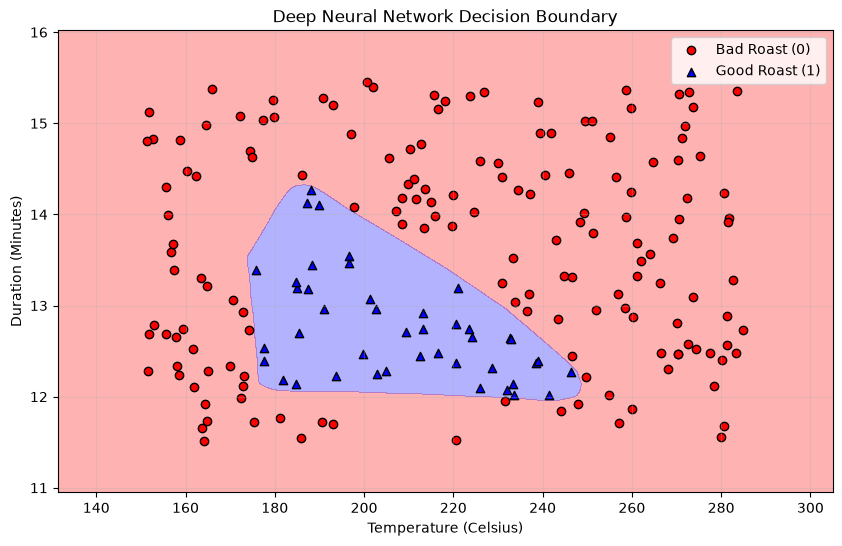

In [12]:
model = nn.Sequential (
    nn.Linear(2,32),
    nn.ReLU(),
    nn.Linear(32,32),
    nn.ReLU(),
    nn.Linear(32,1),
    nn.Sigmoid()
    )
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print("Training the  deep NN ")
epochs=1000
for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X_tensor)
    loss = criterion(predictions, Y_tensor)
    loss.backward()
    optimizer.step()

    if(epoch+1)%200==0:
        print(f'Epoch[{epoch+1}],Loss:{loss.item():.4f}')
print ("Training Complete \n")
model.eval()
x0_min, x0_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
x1_min, x1_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 200), np.linspace(x1_min, x1_max, 200))

grid_tensor = torch.tensor(np.c_[xx0.ravel(), xx1.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z = model(grid_tensor).numpy()
    Z = Z.reshape(xx0.shape)

xx0_unscaled = xx0 * X_std[0]+ X_mean[0]
xx1_unscaled = xx1 * X_std[1] + X_mean[1]

plt.figure(figsize=(10, 6))

# Plot the new curved decision boundary
plt.contourf(xx0_unscaled, xx1_unscaled, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['red', 'blue'])

plt.scatter(X[Y[:, 0] == 0][:, 0], X[Y[:, 0] == 0][:, 1], color='red', label='Bad Roast (0)', edgecolors='k')
plt.scatter(X[Y[:, 0] == 1][:, 0], X[Y[:, 0] == 1][:, 1], color='blue', label='Good Roast (1)', edgecolors='k', marker='^')

plt.title('Deep Neural Network Decision Boundary')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Duration (Minutes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()